In [64]:
import kwant
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eig
from scipy.optimize import fmin

In [65]:
#参数
m=2.5*10**(-3)
a=1


t =1/(2*m*a**2)
mu = 0

dela = 1
af=100
my=0.5
mz=0.5

chaodaojiao = np.pi/2

Lpot=499
centerpot=2
Rpot=Lpot

#矩阵信息
sx = np.array([[0, 1], [1, 0]], complex)
sy = np.array([[0, -1j], [1j, 0]], complex)
sz = np.array([[1, 0], [0, -1]], complex)
s0 = np.array([[1, 0], [0, 1]], complex)

#左边矩阵信息
HL_block=(-mu+2*t)*s0 + my*sy + mz*sz
Delta_L= -1j * dela * np.exp(-1j*chaodaojiao/2) * sy
H_L_onsite=np.block([
        [ HL_block,        Delta_L        ],
        [ Delta_L.conj().T, -HL_block.conj()]
    ])

H_L_right_to_left_hop_block=-1*(t*s0+1j*af*sy/(2*a))
H_L_right_to_left_hop=np.block([
        [ H_L_right_to_left_hop_block,        np.zeros((2,2))],
        [ np.zeros((2,2)), -H_L_right_to_left_hop_block.conj()]
    ])

hop= H_L_right_to_left_hop
#中间矩阵信息
H_center_to_L= hop
H_R_to_center= hop

H_center_block= (-mu+2*t)*s0 + my*sy + mz*sz
H_center=np.block([
        [ H_center_block,        np.zeros((2,2)) ],
        [ np.zeros((2,2)) , -H_center_block.conj()]
    ])
    
H_center_right_to_left_hop= hop



#右边矩阵信息
HR_block= (-mu+2*t)*s0 + my*sy + mz*sz 
Delta_R= -1j * dela * np.exp(+1j*chaodaojiao/2) * sy
H_R_onsite=np.block([
        [ HR_block,        Delta_R        ],
        [ Delta_R.conj().T, -HR_block.conj()]
    ])

H_R_right_to_left_hop= hop


In [66]:
def build_block_hamiltonian(
    Lpot, centerpot, Rpot,
    H_L_onsite, H_center, H_R_onsite,
    H_hop_L, H_hop_center, H_hop_R,
    H_hop_center_to_L, H_hop_R_to_center
):
    N = Lpot + centerpot + Rpot
    dim = 4 * N
    H = np.zeros((dim, dim), dtype=complex)

    def set_block(i, j, mat):
        H[4*i:4*(i+1), 4*j:4*(j+1)] = mat

    # 对角块
    for i in range(N):
        if i < Lpot:
            set_block(i, i, H_L_onsite)
        elif i < Lpot + centerpot:
            set_block(i, i, H_center)
        else:
            set_block(i, i, H_R_onsite) 

    # 区内 hopping
    for i in range(N - 1):
        if i < Lpot - 1:  # Left
            set_block(i, i+1, H_hop_L)
            set_block(i+1, i, H_hop_L.conj().T)
        elif Lpot <= i < Lpot + centerpot - 1:  # Center
            set_block(i, i+1, H_hop_center)
            set_block(i+1, i, H_hop_center.conj().T)
        else:  # Right
            set_block(i, i+1, H_hop_R)
            set_block(i+1, i, H_hop_R.conj().T)

    # 区域间连接
    # L <-> Center
    i = Lpot - 1
    set_block(i, i+1, H_hop_center_to_L)
    set_block(i+1, i, H_hop_center_to_L.conj().T)

    # Center <-> R
    i = Lpot + centerpot - 1
    set_block(i, i+1, H_hop_R_to_center)
    set_block(i+1, i, H_hop_R_to_center.conj().T)

    return H

<>:42: SyntaxWarning: invalid escape sequence '\p'
<>:42: SyntaxWarning: invalid escape sequence '\p'
C:\Users\taoji\AppData\Local\Temp\ipykernel_13064\1766502452.py:42: SyntaxWarning: invalid escape sequence '\p'
  plt.title('Energy spectrum vs $\phi$ ')


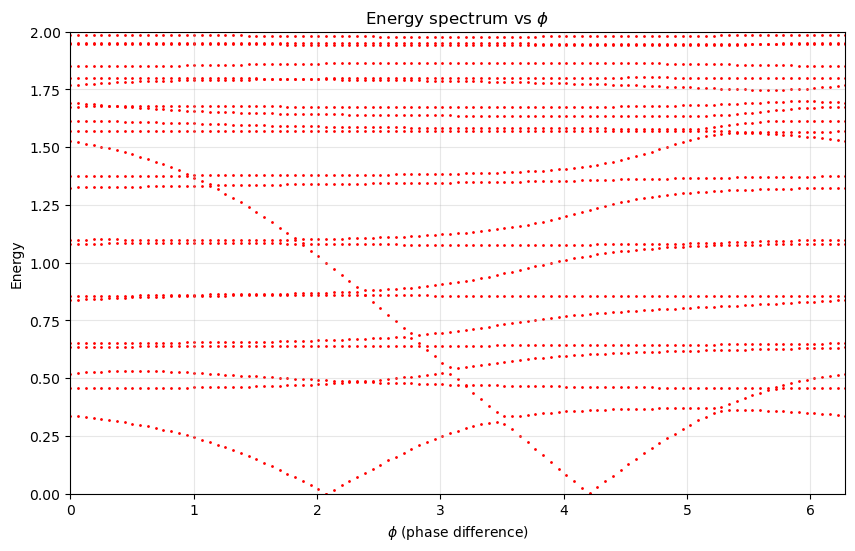

In [14]:
phis = np.linspace(0, 2*np.pi, 101)
all_energies = []


for phi in phis:

    Delta_L = -1j * dela * np.exp(-1j * phi / 2) * sy
    H_L_onsite = np.block([
        [HL_block,      Delta_L],
        [Delta_L.conj().T, -HL_block.conj()]
    ])


    Delta_R = -1j * dela * np.exp(+1j * phi / 2) * sy
    H_R_onsite = np.block([
        [HR_block,      Delta_R],
        [Delta_R.conj().T, -HR_block.conj()]
    ])


    H = build_block_hamiltonian(
        Lpot, centerpot, Rpot,
        H_L_onsite, H_center, H_R_onsite,
        hop, hop, hop,
        hop, hop
    )


    eigvals = np.linalg.eigvalsh(H)
    all_energies.append(eigvals)

all_energies = np.array(all_energies)


plt.figure(figsize=(10, 6))
phis_flat = np.repeat(phis, all_energies.shape[1])
energies_flat = all_energies.flatten()
plt.scatter(phis_flat, energies_flat, c='red', s=1)

plt.xlabel(r'$\phi$ (phase difference)')
plt.ylabel('Energy')
plt.title('Energy spectrum vs $\phi$ ')
plt.xlim(0, 2*np.pi)
plt.ylim(0, 2*dela)
plt.grid(True, alpha=0.3)
plt.show()

In [67]:

def Gr_DD_MS_gaiyixia(H, wn):
    I = np.eye(H.shape[0], dtype=complex)
    A_DD_wn = 1j*wn*I -H

    G_DD_wn = np.linalg.inv(A_DD_wn)
    f_E= 1/(1+np.exp((wn - mu)/KBT))
    G_DD_wn_xiao=f_E*(G_DD_wn.conj()-G_DD_wn)
    return G_DD_wn_xiao , A_DD_wn 

def matsubara_list(shumu):
    n_max =  shumu
    n_vals = np.arange(-n_max, n_max+1 )
    wn = (2 * n_vals + 1) * np.pi * KBT

    return wn.tolist()

def J_wn(G_DD_wn, hop):
    d = hop.shape[0]

    G_q_q1 = G_DD_wn[q*d:(q+1)*d, (q+1)*d:(q+2)*d]
    G_q1_q = G_DD_wn[(q+1)*d:(q+2)*d, q*d:(q+1)*d]

    Jmat = hop.conj().T @ G_q1_q - G_q_q1 @ hop
    d_e = d //2
    return np.trace(Jmat[:d_e, :d_e])*(-1j)*KBT##什么回事（j）

def J_matsubara_sum(shumu):
    wn_list = matsubara_list(shumu)
    J_sum = 0.0 
    for wn in wn_list:
        G_DD_wn, _= Gr_DD_MS_gaiyixia(
            H , wn
        )

        J_sum += (J_wn(G_DD_wn, hop))
    return (J_sum)

In [71]:
shumu=500
KBT=3.5*dela*1e-3

Lpot=499
q=Lpot+1
centerpot=2
Rpot=Lpot

# 主循环：计算 J vs phi
phis = np.linspace(0, 2*np.pi, 11)
J_list = []

for phi in phis:
    Delta_L = -1j * dela * np.exp(-1j * phi / 2) * sy
    H_L_onsite = np.block([
        [HL_block,      Delta_L],
        [Delta_L.conj().T, -HL_block.conj()]
    ])

    Delta_R = -1j * dela * np.exp(+1j * phi / 2) * sy
    H_R_onsite = np.block([
        [HR_block,      Delta_R],
        [Delta_R.conj().T, -HR_block.conj()]
    ])

    H = build_block_hamiltonian(
        Lpot, centerpot, Rpot,
        H_L_onsite, H_center, H_R_onsite,
        hop, hop, hop,
        hop, hop
    )

    J = J_matsubara_sum(shumu)
    J_list.append(J)
    if phi:
        print(f"完成 {phi}/{len(phis)} 个 φ")
# 画图
plt.figure(figsize=(10, 6))
plt.plot(phis, J_list, 'r-', marker='o')
plt.xlabel(r'$\phi$ (phase difference)')
plt.ylabel('J (current)')
plt.title('Josephson current J vs $\phi$')
plt.xlim(0, 2*np.pi)
plt.grid(True, alpha=0.3)
plt.show()

<>:42: SyntaxWarning: invalid escape sequence '\p'
<>:42: SyntaxWarning: invalid escape sequence '\p'
C:\Users\taoji\AppData\Local\Temp\ipykernel_13064\3654499417.py:42: SyntaxWarning: invalid escape sequence '\p'
  plt.title('Josephson current J vs $\phi$')
C:\Users\taoji\AppData\Local\Temp\ipykernel_13064\3654499417.py:42: SyntaxWarning: invalid escape sequence '\p'
  plt.title('Josephson current J vs $\phi$')


KeyboardInterrupt: 

<>:102: SyntaxWarning: invalid escape sequence '\p'
<>:102: SyntaxWarning: invalid escape sequence '\p'
C:\Users\taoji\AppData\Local\Temp\ipykernel_13064\3228609574.py:102: SyntaxWarning: invalid escape sequence '\p'
  plt.title('Energy spectrum vs $\phi$ (Kwant, closed system)')


开始计算（每个 φ 计算 200 个低能本征值，系统规模 4000x4000 sparse）...
完成 1/101 个 φ
完成 11/101 个 φ
完成 21/101 个 φ
完成 31/101 个 φ
完成 41/101 个 φ
完成 51/101 个 φ
完成 61/101 个 φ
完成 71/101 个 φ
完成 81/101 个 φ
完成 91/101 个 φ
完成 101/101 个 φ


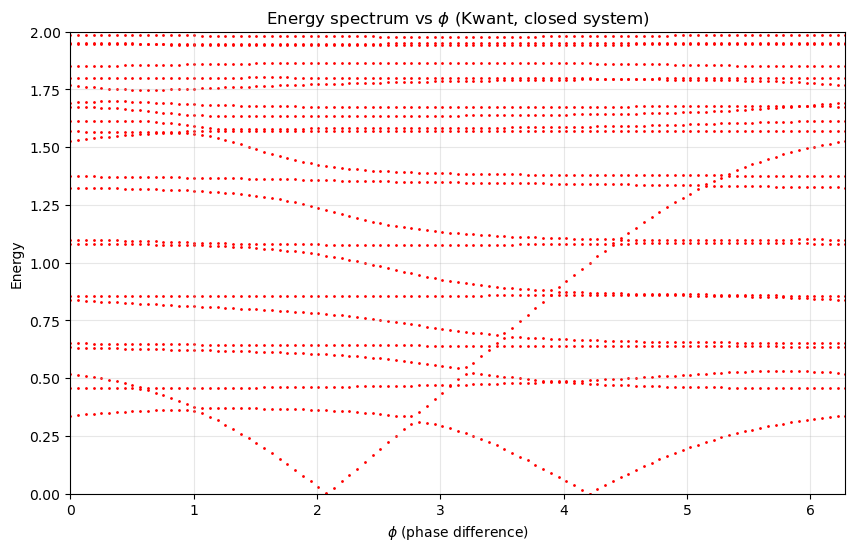

In [22]:
import kwant
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse.linalg import eigsh
# 参数 
m = 2.5e-3
a = 1
t = 1 / (2 * m * a**2)
mu = 0
dela = 1
af = 100
my = 0.5
mz = 0.5

Lpot = 499
centerpot = 2
Rpot = 499
N_total = Lpot + centerpot + Rpot  # 1000 sites

# Pauli 矩阵
sx = np.array([[0, 1], [1, 0]], dtype=complex)
sy = np.array([[0, -1j], [1j, 0]], dtype=complex)
sz = np.array([[1, 0], [0, -1]], dtype=complex)
s0 = np.array([[1, 0], [0, 1]], dtype=complex)

# 公共块
HL_block = (-mu + 2*t) * s0 + my * sy + mz * sz
HR_block = (-mu + 2*t) * s0 + my * sy + mz * sz
H_center_block = (-mu + 2*t) * s0 + my * sy + mz * sz

hop_block = - (t * s0 + 1j * af * sy / (2 * a))
hop = np.block([
    [hop_block, np.zeros((2,2), dtype=complex)],
    [np.zeros((2,2), dtype=complex), -hop_block.conj()]
])

H_center = np.block([
    [H_center_block, np.zeros((2,2), dtype=complex)],
    [np.zeros((2,2), dtype=complex), -H_center_block.conj()]
])

# Kwant 设置: 1D 链, 每个站点 norbs=4 (BdG 表象)
lat = kwant.lattice.chain(norbs=4)

phis = np.linspace(0, 2*np.pi, 101)
all_energies = []

print("开始计算（每个 φ 计算 200 个低能本征值，系统规模 4000x4000 sparse）...")
for idx, phi in enumerate(phis):
    # 更新 Delta
    Delta_L = -1j * dela * np.exp(-1j * phi / 2) * sy
    H_L_onsite = np.block([
        [HL_block, Delta_L],
        [Delta_L.conj().T, -HL_block.conj()]
    ])

    Delta_R = -1j * dela * np.exp(+1j * phi / 2) * sy
    H_R_onsite = np.block([
        [HR_block, Delta_R],
        [Delta_R.conj().T, -HR_block.conj()]
    ])

    # 构建 Kwant 系统 (封闭, 无导线)
    syst = kwant.Builder()

    # 添加站点 onsite 矩阵
    for i in range(N_total):
        if i < Lpot:
            syst[lat(i)] = H_L_onsite
        elif i < Lpot + centerpot:
            syst[lat(i)] = H_center
        else:
            syst[lat(i)] = H_R_onsite

    # 添加 hopping (所有相邻站点用相同 hop, 注意方向)
    syst[kwant.builder.HoppingKind((1,), lat)] = hop

    # 最终化系统
    syst = syst.finalized()

    # 获取 sparse Hamiltonian
    ham = syst.hamiltonian_submatrix(sparse=True).tocsc()

    # 计算最低 200 个本征值 (围绕 E=0, 匹配低能谱; 全谱太慢/内存大)
    eigvals = eigsh(ham, k=200, sigma=0, return_eigenvectors=False)
    all_energies.append(np.sort(eigvals))  # 排序以匹配原 eigvalsh

    if idx % 10 == 0:
        print(f"完成 {idx+1}/{len(phis)} 个 φ")

all_energies = np.array(all_energies)

# 绘图 (红色散点)
plt.figure(figsize=(10, 6))
phis_flat = np.repeat(phis, all_energies.shape[1])
energies_flat = all_energies.flatten()
plt.scatter(phis_flat, energies_flat, c='red', s=1)

plt.xlabel(r'$\phi$ (phase difference)')
plt.ylabel('Energy')
plt.title('Energy spectrum vs $\phi$ (Kwant, closed system)')
plt.xlim(0, 2*np.pi)
plt.ylim(0, 2*dela)
plt.grid(True, alpha=0.3)
plt.show()